In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Import the data
df2 = pd.read_csv("general_time_error_data_bench_3.csv")
print(df2)

     size  partitions           eps  omega           err         rk  \
0     100          10  1.000000e-05    0.1  1.465850e-13  20.000000   
1     100          10  1.000000e-05    0.9  2.008952e-13  20.000000   
2     100          10  1.000000e-10    0.1  2.563643e-13  20.000000   
3     100          10  1.000000e-10    0.9  1.155112e-13  20.000000   
4     200          10  1.000000e-05    0.1  7.214843e-13  20.000000   
5     200          10  1.000000e-05    0.9  1.000941e-13  20.000000   
6     200          10  1.000000e-10    0.1  1.609905e-13  20.000000   
7     200          10  1.000000e-10    0.9  9.956343e-13  20.000000   
8     400          10  1.000000e-05    0.1  7.015437e-13  20.000000   
9     400          10  1.000000e-05    0.9  7.799602e-13  20.000000   
10    400          10  1.000000e-10    0.1  8.372478e-13  20.000000   
11    400          10  1.000000e-10    0.9  1.255371e-12  20.000000   
12    500          10  1.000000e-05    0.1  1.101271e-12  20.000000   
13    

In [ ]:
omega=0.1
eps = 1e-3
"""
filtered_df= df[(df["omega"]==omega)&(df["eps"]==eps)]
filtered_df=filtered_df[["partitions","time","time_tight_0","time_tight_1","time_tight_2","time_tight_3"]]
#print(filtered_df)
"""

omega =0.1
eps = 1e-5
filtered_df=df[(df2["omega"]==omega)&(df["eps"]==eps)]
filtered_df=filtered_df[["size","eps","time","time_tight_0","time_tight_1","time_tight_2","time_tight_3"]]




slope,intercept = np.polyfit(np.log(filtered_df2['size']), np.log(filtered_df2['time']), 1)
slope2,intercept2 = np.polyfit(np.log(filtered_df2['size']), np.log(filtered_df2['time_tight_2']), 1)


     size      eps        time  time_tight_0  time_tight_1  time_tight_2  \
0     100  0.00001    0.008802      0.008983      0.011334      0.021038   
4     200  0.00001    0.016343      0.028999      0.034348      0.052346   
8     400  0.00001    0.077750      0.077750      0.093948      0.142666   
12    500  0.00001    0.128236      0.132208      0.166760      0.121638   
16    800  0.00001    0.271525      0.247135      0.270438      0.278837   
20   1000  0.00001    0.348986      0.373105      0.342350      0.377450   
24   2000  0.00001    1.677083      1.161475      1.022417      1.029185   
28   4000  0.00001   15.591203      3.984532      3.521183      3.484223   
32   5000  0.00001   33.548546      6.877026      7.330080      7.350465   
36   8000  0.00001  140.960250     16.271048     15.755299     15.911114   
40  10000  0.00001  223.068847     23.440583     23.534685     24.746324   

    time_tight_3  
0       0.024117  
4       0.042750  
8       0.113895  
12      0.1

In [57]:

label_map = {
    'time': 'LAPACK gesdd',
    'time_tight_0': 'Distributed',
    'time_tight_1': 'Incremental',
    'time_tight_2': '2-level Distributed',
    'time_tight_3': '2-level Incremental',
}

markers = ['o', 's', 'd', 's', 'd', '*']
colors = ['k', 'g', 'r', 'c', 'm', 'k']
linestyles = ['-', ':', ':','-.','-.', '--']

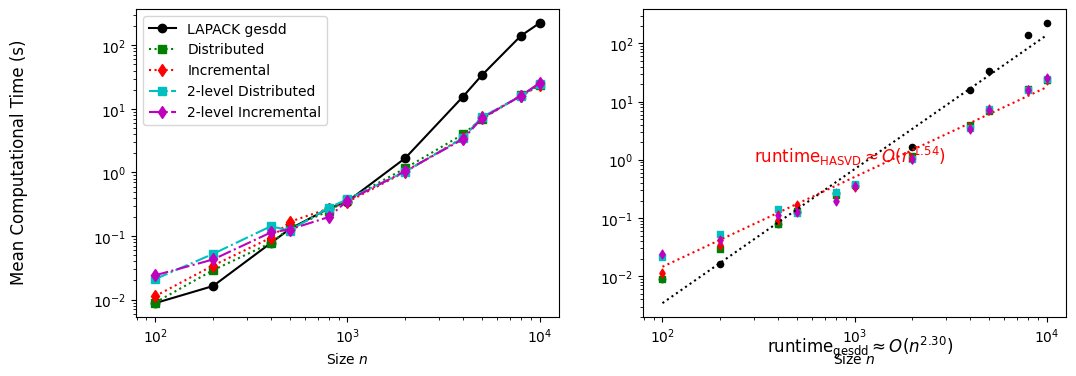

In [68]:
fig=plt.figure(figsize=(12, 4))
fig.supylabel('Mean Computational Time (s)')

ax1 = fig.add_subplot(1,2,1)
for i, col in enumerate(["time","time_tight_0","time_tight_1","time_tight_2","time_tight_3"]):
    marker = markers[i]
    ax1 = filtered_df2.plot(
        x='size',
        y=col,
        ax=ax1,
        marker=marker,
        color=colors[i % len(colors)],
        linestyle=linestyles[i],
        label=label_map[col],
    )
ax1.set_xlabel("Size $n$")
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylabel(None)

ax2 = fig.add_subplot(1,2,2)
for i, col in enumerate(["time","time_tight_0","time_tight_1","time_tight_2","time_tight_3"]):
    marker = markers[i]
    ax2 = filtered_df2.plot.scatter(
        x='size',
        y=col,
        ax=ax2,
        marker=marker,
        color=colors[i],
        label=label_map[col],
    )
    
plt.plot(np.linspace(100,10000),np.exp(intercept)*(np.linspace(100,10000)**slope)
    ,color="k",linestyle=":")
plt.text(350, 0.0005, f'$\\text{{runtime}}_{{\\text{{gesdd}}}} \\approx O(n^{{{slope:.2f}}})$', fontsize=12, color='black')

plt.plot(np.linspace(100,10000),np.exp(intercept2)*(np.linspace(100,10000)**slope2)
    ,color="r",linestyle=":")
plt.text(300, 0.9, f'$\\text{{runtime}}_{{\\text{{HASVD}}}} \\approx O(n^{{{slope2:.2f}}})$', fontsize=12, color='red')

ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_ylabel(None)
ax2.set_xlabel("Size $n$")

ax2.get_legend().remove()